# Corrected infraction-category experiment

This is a corrected rerun of the earlier category experiment (notebook 13). That run retained only 7 `deficiencyDesc` categories because of an overly strict reading of the feature cap, covering 76.4% of infraction rows. This version uses the pre-specified maximum of 15 categories, covering closer to 93%. Same question as before: does knowing the type of previous infraction add anything beyond counts and severity?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score,
                              recall_score, f1_score, accuracy_score, confusion_matrix,
                              precision_recall_curve, roc_curve)

TEST_START = pd.Timestamp("2026-04-10")

## Normalized deficiency categories

Case and whitespace normalized, no manual merging of categories that only look similar.

In [2]:
raw = pd.read_csv("../Dinesafe.csv", dtype=str, low_memory=False)

dedup_cols = ["estId", "inspectionDate", "typeDesc", "deficiencyDesc", "severity", "OutcomeDate", "OutcomeDesc", "amountFined"]
raw_clean = raw.drop_duplicates(subset=dedup_cols, keep="first").copy()
raw_clean["inspectionDate"] = pd.to_datetime(raw_clean["inspectionDate"])
raw_clean["norm_def"] = raw_clean["deficiencyDesc"].str.strip().str.upper().str.replace(r"\s+", " ", regex=True)

print("raw rows:", len(raw), "-> after removing confirmed duplicate infractions:", len(raw_clean))
print("distinct normalized deficiencyDesc categories:", raw_clean["norm_def"].nunique())

raw rows: 115899 -> after removing confirmed duplicate infractions: 115539
distinct normalized deficiencyDesc categories: 36


## Freezing the category vocabulary before the test period

The top 15 categories are chosen using only infraction rows dated before the test period starts (2026-04-10), so no test-period information enters the category selection.

In [3]:
pre_test = raw_clean[raw_clean["inspectionDate"] < TEST_START]
vc = pre_test["norm_def"].value_counts()
total_pre_test = pre_test["norm_def"].notna().sum()

RETAINED = vc.head(15).index.tolist()
print("categories retained:", len(RETAINED))
print("coverage of pre-test infraction rows:", round(vc.head(15).sum() / total_pre_test, 4))

categories retained: 15
coverage of pre-test infraction rows: 0.929


In [4]:
SLUGS = ["cat_5c_maintenance_rooms", "cat_05_non_food_surfaces", "cat_3a_handwashing_sink",
         "cat_a_admin_requirements", "cat_2c_utensil_procedures", "cat_4c_sink_supplies",
         "cat_4d_mechanical_washer", "cat_5b_thermometers", "cat_8a_pest_control",
         "cat_administrative_requirements", "cat_03_employee_hygiene", "cat_04_food_contact_surfaces",
         "cat_2b_food_contamination", "cat_6b_sanitary_supplies", "cat_02_food_contamination"]
assert len(SLUGS) == 15
CAT_MAP = dict(zip(RETAINED, SLUGS))

for cat, slug in CAT_MAP.items():
    print(f"{slug}: {cat}  ({vc[cat]} pre-test rows)")

cat_5c_maintenance_rooms: 5C. PROPER MAINTENANCE / WASHING OF ROOMS (INCLUDING WASHROOMS)  (28804 pre-test rows)
cat_05_non_food_surfaces: 05. MAINTENANCE / SANITATION OF NON-FOOD CONTACT SURFACES / EQUIPMENT  (6173 pre-test rows)
cat_3a_handwashing_sink: 3A. SEPARATE AND CONVENIENT HAND WASHING SINK(S)  (4178 pre-test rows)
cat_a_admin_requirements: A. OPERATOR FAIL TO MEET ADMINISTRATIVE REQUIREMENTS OF  (2760 pre-test rows)
cat_2c_utensil_procedures: 2C. PROPER UTENSILS/EQUIPMENT AND/OR PROCEDURES USED TO ENSURE  (2568 pre-test rows)
cat_4c_sink_supplies: 4C. PROVISION AND PROPER USE OF SINKS AND SUPPLIES FOR MANUAL  (1748 pre-test rows)
cat_4d_mechanical_washer: 4D. PROPERLY EQUIPPED / MAINTAINED MECHANICAL WASHER FOR  (1724 pre-test rows)
cat_5b_thermometers: 5B. ACCURATE INDICATING AND EASILY READABLE THERMOMETERS  (1561 pre-test rows)
cat_8a_pest_control: 8A. ADEQUATE PEST CONTROL  (1320 pre-test rows)
cat_administrative_requirements: ADMINISTRATIVE REQUIREMENTS  (1237 pre-test 

15 categories, 92.9% coverage of pre-test infraction rows, well up from the 7 categories / 76.4% used in the earlier run.

## Building the 365/730-day category-history features

Same approach as notebook 13: category counts only exist for current-sourced rows (`deficiencyDesc` isn't in the historical files), so historical-sourced rows get zero for every category feature, not a missing value. The existing 15 features already count historical infractions correctly by total/severity.

In [5]:
raw_clean["slug"] = raw_clean["norm_def"].map(CAT_MAP)

cat_counts = (
    raw_clean.dropna(subset=["slug"])
    .groupby(["estId", "inspectionDate", "slug"]).size()
    .unstack(fill_value=0)
)
for s in SLUGS:
    if s not in cat_counts.columns:
        cat_counts[s] = 0
cat_counts = cat_counts[SLUGS].reset_index()

long = pd.read_csv("../outputs/inspection_level_longitudinal.csv", parse_dates=["inspectionDate"], low_memory=False)
long = long.sort_values(["estId", "inspectionDate"]).reset_index(drop=True)
long = long.merge(cat_counts, on=["estId", "inspectionDate"], how="left")
for s in SLUGS:
    long[s] = long[s].fillna(0).astype(int)

print("longitudinal rows:", len(long))
print("rows with any retained-category infraction:", (long[SLUGS].sum(axis=1) > 0).sum())

longitudinal rows: 262547
rows with any retained-category infraction: 34356


In [6]:
long["is_non_pass"] = long["inspectionStatus"].isin(["Conditional Pass", "Closed"]).astype(int)

def rolling_window(g, days, prefix, cols):
    g = g.reset_index()
    dates = g["inspectionDate"].values.astype("datetime64[D]")
    out = {"orig_index": g["index"]}
    for c in cols:
        vals = g[c].to_numpy()
        cs = np.concatenate([[0], np.cumsum(vals)])
        lower_edge = dates - np.timedelta64(days, "D")
        low_idx = np.searchsorted(dates, lower_edge, side="left")
        idx_arr = np.arange(len(g))
        out[f"{prefix}_{c}"] = cs[idx_arr] - cs[low_idx]
    return pd.DataFrame(out)

def rolling_count(g, days, prefix):
    g = g.reset_index()
    dates = g["inspectionDate"].values.astype("datetime64[D]")
    lower_edge = dates - np.timedelta64(days, "D")
    low_idx = np.searchsorted(dates, lower_edge, side="left")
    idx_arr = np.arange(len(g))
    return pd.DataFrame({"orig_index": g["index"], f"{prefix}_n_inspections": idx_arr - low_idx})

long["_infr_"] = long["n_infractions"]; long["_crucial_"] = long["n_crucial"]; long["_nonpass_"] = long["is_non_pass"]
base_cols = ["_infr_", "_crucial_", "_nonpass_"]

rolled_365 = long.groupby("estId", group_keys=False).apply(rolling_window, days=365, prefix="prior_365d", cols=base_cols + SLUGS).set_index("orig_index")
rolled_730 = long.groupby("estId", group_keys=False).apply(rolling_window, days=730, prefix="prior_730d", cols=base_cols + SLUGS).set_index("orig_index")
n_365 = long.groupby("estId", group_keys=False).apply(rolling_count, days=365, prefix="prior_365d").set_index("orig_index")
n_730 = long.groupby("estId", group_keys=False).apply(rolling_count, days=730, prefix="prior_730d").set_index("orig_index")

long_feat = long.join(rolled_365).join(rolled_730).join(n_365).join(n_730)
long_feat = long_feat.rename(columns={
    "prior_365d__infr_": "prior_365d_total_infractions", "prior_365d__crucial_": "prior_365d_crucial_infractions",
    "prior_365d__nonpass_": "prior_365d_n_non_pass", "prior_730d__infr_": "prior_730d_total_infractions",
    "prior_730d__crucial_": "prior_730d_crucial_infractions", "prior_730d__nonpass_": "prior_730d_n_non_pass",
})

cat_feature_cols = []
for s in SLUGS:
    cat_feature_cols.append(f"prior_365d_{s}")
    cat_feature_cols.append(f"prior_730d_{s}")

print("category feature count:", len(cat_feature_cols))
assert len(cat_feature_cols) == 30

category feature count: 30


## Merge onto the prediction-event dataset

In [7]:
pred = pd.read_csv("../outputs/prediction_events_current_v1.csv",
                    parse_dates=["inspectionDate", "prev_inspectionDate"], low_memory=False)

merge_cols = ["estId", "inspectionDate", "prior_730d_total_infractions", "prior_730d_n_non_pass",
              "prior_730d_crucial_infractions", "prior_730d_n_inspections"] + cat_feature_cols
df = pred.merge(long_feat[merge_cols], on=["estId", "inspectionDate"], how="left")

assert len(df) == len(pred)
for c in cat_feature_cols:
    assert df[c].isna().sum() == 0
    assert (df[c] >= 0).all()
assert not df.duplicated(subset=["estId", "inspectionDate"]).any()
print("merged rows:", len(df), "- no missing/negative category features, no duplicate prediction events")

merged rows: 69766 - no missing/negative category features, no duplicate prediction events


## Feature validation

Brute-force recomputation of all 30 category counts (15 categories x 2 windows) on 300 random rows.

In [8]:
rng = np.random.default_rng(0)
sample_idx = rng.choice(df.index, size=300, replace=False)
mismatches = 0

for i in sample_idx:
    row = df.loc[i]
    est = row["estId"]; t = row["inspectionDate"]
    hist_infr = raw_clean[raw_clean["estId"] == est]
    hist_infr = hist_infr[hist_infr["inspectionDate"] < t]

    for days, prefix in [(365, "prior_365d"), (730, "prior_730d")]:
        window = hist_infr[hist_infr["inspectionDate"] >= t - pd.Timedelta(days=days)]
        for cat_str, slug in CAT_MAP.items():
            expected = (window["norm_def"] == cat_str).sum()
            got = row[f"{prefix}_{slug}"]
            if expected != got:
                mismatches += 1

print("brute-force mismatches on 300 sampled rows x 15 categories x 2 windows (must be 0):", mismatches)
assert mismatches == 0

brute-force mismatches on 300 sampled rows x 15 categories x 2 windows (must be 0): 0


## Feature sets: 15-feature baseline vs 45-feature category model

In [9]:
BASE = ["days_since_previous_inspection", "prev_non_pass", "prev_total_infractions",
        "prev_minor", "prev_significant", "prev_crucial", "n_inspections_seen_so_far"]
HIST365 = ["prior_365d_n_inspections", "prior_365d_n_non_pass",
           "prior_365d_total_infractions", "prior_365d_crucial_infractions"]
HIST730 = ["prior_730d_n_inspections", "prior_730d_n_non_pass",
           "prior_730d_total_infractions", "prior_730d_crucial_infractions"]

FEATURES_15 = BASE + HIST365 + HIST730
FEATURES_45 = FEATURES_15 + cat_feature_cols
assert len(FEATURES_15) == 15
assert len(FEATURES_45) == 45
assert not any(c.startswith("cat_") or "_cat_" in c for c in FEATURES_15)

identifier_cols = {"estId", "oldEstId", "_id", "unique_id"}
outcome_cols = {"OutcomeDate", "OutcomeDesc", "amountFined", "inspectionStatus"}
assert identifier_cols.isdisjoint(FEATURES_45)
assert outcome_cols.isdisjoint(FEATURES_45)

## Strict temporal split, unchanged

In [10]:
df = df.sort_values("inspectionDate").reset_index(drop=True)

unique_dates = np.sort(df["inspectionDate"].unique())
n_dates = len(unique_dates)
train_cut = unique_dates[int(n_dates * 0.70)]
val_cut = unique_dates[int(n_dates * 0.85)]

train = df[df["inspectionDate"] < train_cut].copy()
val = df[(df["inspectionDate"] >= train_cut) & (df["inspectionDate"] < val_cut)].copy()
test = df[df["inspectionDate"] >= val_cut].copy()

assert len(train) == 45334 and len(val) == 11740 and len(test) == 12692
assert test["inspectionDate"].min() == TEST_START
assert train["inspectionDate"].max() < val["inspectionDate"].min()
assert val["inspectionDate"].max() < test["inspectionDate"].min()
print("split unchanged: train 45,334 / val 11,740 / test 12,692")

split unchanged: train 45,334 / val 11,740 / test 12,692


## Leakage checks

In [11]:
assert (df["inspectionDate"] > df["prev_inspectionDate"]).all()
assert df["inspectionDate"].min() >= pd.Timestamp("2023-11-10")
assert df["inspectionDate"].max() <= pd.Timestamp("2026-09-08")
# category vocabulary was derived only from raw infraction rows dated before TEST_START, done above
print("leakage checks passed")

leakage checks passed


## Train both models, same rows, same fixed CatBoost config

In [12]:
def run_model(features, label):
    X_train, y_train = train[features], train["target"]
    X_val, y_val = val[features], val["target"]
    X_test, y_test = test[features], test["target"]

    model = CatBoostClassifier(
        iterations=300, depth=4, learning_rate=0.05, loss_function="Logloss",
        auto_class_weights="Balanced", random_seed=42, verbose=False,
    )
    model.fit(X_train, y_train)

    val_proba = model.predict_proba(X_val)[:, 1]
    val_pr_auc = average_precision_score(y_val, val_proba)
    val_roc_auc = roc_auc_score(y_val, val_proba)

    thresh_rows = []
    for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
        p = (val_proba >= t).astype(int)
        thresh_rows.append({"threshold": t, "f1": f1_score(y_val, p, zero_division=0)})
    thresh_df = pd.DataFrame(thresh_rows)
    best_t = thresh_df.loc[thresh_df["f1"].idxmax(), "threshold"]

    test_proba = model.predict_proba(X_test)[:, 1]
    test_pred = (test_proba >= best_t).astype(int)

    metrics = {
        "label": label,
        "val_pr_auc": val_pr_auc, "val_roc_auc": val_roc_auc, "threshold": best_t,
        "test_pr_auc": average_precision_score(y_test, test_proba),
        "test_roc_auc": roc_auc_score(y_test, test_proba),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0),
        "test_f1": f1_score(y_test, test_pred, zero_division=0),
        "test_accuracy": accuracy_score(y_test, test_pred),
    }
    cm = confusion_matrix(y_test, test_pred)
    return model, metrics, cm, test_proba

In [13]:
model15, metrics15, cm15, proba15 = run_model(FEATURES_15, "catboost_15_baseline")
print(metrics15)
print(cm15)

{'label': 'catboost_15_baseline', 'val_pr_auc': 0.17119999099665015, 'val_roc_auc': 0.7335191135474568, 'threshold': np.float64(0.7), 'test_pr_auc': 0.17421968990108275, 'test_roc_auc': 0.7337115866223876, 'test_precision': 0.20975965040058267, 'test_recall': 0.3018867924528302, 'test_f1': 0.2475290073055436, 'test_accuracy': 0.8620390797352663}
[[10653  1085]
 [  666   288]]


In [14]:
saved = pd.read_csv("../outputs/tuned_model_results.csv").iloc[0]
print("saved Prompt 14/15 test PR-AUC:", saved["test_pr_auc"], " reproduced:", metrics15["test_pr_auc"])
assert abs(saved["test_pr_auc"] - metrics15["test_pr_auc"]) < 1e-9
assert abs(saved["test_roc_auc"] - metrics15["test_roc_auc"]) < 1e-9
print("baseline reproduces the earlier tuned result exactly")

saved Prompt 14/15 test PR-AUC: 0.1742196899010827  reproduced: 0.17421968990108275
baseline reproduces the earlier tuned result exactly


In [15]:
model45, metrics45, cm45, proba45 = run_model(FEATURES_45, "catboost_45_with_15_categories")
print(metrics45)
print(cm45)

{'label': 'catboost_45_with_15_categories', 'val_pr_auc': 0.18042485507948278, 'val_roc_auc': 0.7312769905850754, 'threshold': np.float64(0.7), 'test_pr_auc': 0.17559223191456086, 'test_roc_auc': 0.7324968217686434, 'test_precision': 0.20972886762360446, 'test_recall': 0.27568134171907754, 'test_f1': 0.23822463768115942, 'test_accuracy': 0.8674755751654586}
[[10747   991]
 [  691   263]]


## Comparison

In [16]:
compare = pd.DataFrame([metrics15, metrics45])
compare = compare[["label", "val_pr_auc", "val_roc_auc", "threshold", "test_pr_auc",
                    "test_roc_auc", "test_precision", "test_recall", "test_f1", "test_accuracy"]]
compare

,label,val_pr_auc,val_roc_auc,threshold,test_pr_auc,test_roc_auc,test_precision,test_recall,test_f1,test_accuracy
0,catboost_15_baseline,0.171200,0.733519,0.7,0.174220,0.733712,0.209760,0.301887,0.247529,0.862039
1,catboost_45_with_15_categories,0.180425,0.731277,0.7,0.175592,0.732497,0.209729,0.275681,0.238225,0.867476


Test PR-AUC moves from 0.1742 to 0.1756, a small uptick, while test ROC-AUC drops slightly (0.7337 to 0.7325) and F1 drops more noticeably (0.2475 to 0.2382, mostly from lower recall). Validation PR-AUC actually rose more than test did (0.1712 to 0.1804), which is worth flagging on its own: the two metrics don't move together here, a reminder that a validation-only view of this feature addition would have looked more promising than what the test set actually shows.

Overall this lands in the "essentially flat" range defined for this experiment, not a meaningful improvement, and this holds even with more than double the category coverage (93% vs 76%) compared to the earlier 7-category run. The correction doesn't change the conclusion.

## PR and ROC curves

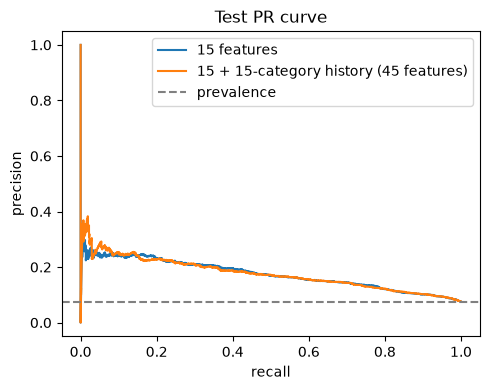

In [17]:
prec15, rec15, _ = precision_recall_curve(test["target"], proba15)
prec45, rec45, _ = precision_recall_curve(test["target"], proba45)

plt.figure(figsize=(5, 4))
plt.plot(rec15, prec15, label="15 features")
plt.plot(rec45, prec45, label="15 + 15-category history (45 features)")
plt.axhline(test["target"].mean(), linestyle="--", color="gray", label="prevalence")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("Test PR curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/catboost_category_corrected_pr_curve.png", dpi=100)
plt.show()

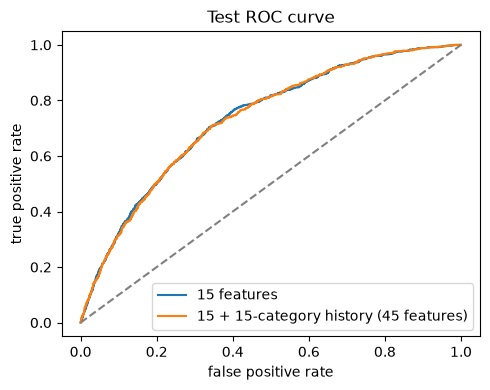

In [18]:
fpr15, tpr15, _ = roc_curve(test["target"], proba15)
fpr45, tpr45, _ = roc_curve(test["target"], proba45)

plt.figure(figsize=(5, 4))
plt.plot(fpr15, tpr15, label="15 features")
plt.plot(fpr45, tpr45, label="15 + 15-category history (45 features)")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("Test ROC curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/catboost_category_corrected_roc_curve.png", dpi=100)
plt.show()

## Feature importance (45-feature model)

In [19]:
importances = model45.get_feature_importance()
imp_df = pd.DataFrame({"feature": FEATURES_45, "importance": importances}).sort_values("importance", ascending=False).reset_index(drop=True)
imp_df

,feature,importance
0,prior_730d_total_infractions,19.990936
1,days_since_previous_inspection,14.872592
2,prev_non_pass,13.150455
3,prior_365d_total_infractions,7.521397
4,n_inspections_seen_so_far,7.258072
5,prev_total_infractions,4.574831
6,prior_730d_crucial_infractions,4.009116
7,prior_365d_n_inspections,3.166734
8,prior_730d_n_inspections,2.705952
9,prior_730d_n_non_pass,2.620100


The original 15 count/severity features still occupy nearly the entire top half of the ranking. A handful of category features (maintenance-of-rooms, handwashing sink, pest control) pick up some importance, but 10 of the 30 category features get exactly zero, the model never splits on them at all. This is consistent with the flat headline result, even with double the category coverage, most of the added features contribute little to nothing.

## Save results

In [20]:
results = pd.DataFrame([
    {"model": "catboost", "feature_set": "15 existing longitudinal features", "n_category_features": 0, "n_total_features": 15,
     "val_pr_auc": metrics15["val_pr_auc"], "val_roc_auc": metrics15["val_roc_auc"], "threshold": metrics15["threshold"],
     "test_pr_auc": metrics15["test_pr_auc"], "test_roc_auc": metrics15["test_roc_auc"],
     "test_precision": metrics15["test_precision"], "test_recall": metrics15["test_recall"],
     "test_f1": metrics15["test_f1"], "test_accuracy": metrics15["test_accuracy"],
     "train_rows": len(train), "val_rows": len(val), "test_rows": len(test),
     "train_start": train["inspectionDate"].min(), "train_end": train["inspectionDate"].max(),
     "val_start": val["inspectionDate"].min(), "val_end": val["inspectionDate"].max(),
     "test_start": test["inspectionDate"].min(), "test_end": test["inspectionDate"].max()},
    {"model": "catboost", "feature_set": "15 existing + 15-category history (30 new features)", "n_category_features": 30, "n_total_features": 45,
     "val_pr_auc": metrics45["val_pr_auc"], "val_roc_auc": metrics45["val_roc_auc"], "threshold": metrics45["threshold"],
     "test_pr_auc": metrics45["test_pr_auc"], "test_roc_auc": metrics45["test_roc_auc"],
     "test_precision": metrics45["test_precision"], "test_recall": metrics45["test_recall"],
     "test_f1": metrics45["test_f1"], "test_accuracy": metrics45["test_accuracy"],
     "train_rows": len(train), "val_rows": len(val), "test_rows": len(test),
     "train_start": train["inspectionDate"].min(), "train_end": train["inspectionDate"].max(),
     "val_start": val["inspectionDate"].min(), "val_end": val["inspectionDate"].max(),
     "test_start": test["inspectionDate"].min(), "test_end": test["inspectionDate"].max()},
])
results.to_csv("../outputs/catboost_category_corrected_results.csv", index=False)

category_summary = pd.DataFrame([
    {"category": cat, "frequency": int(vc[cat]), "coverage_fraction": round(vc[cat] / total_pre_test, 4),
     "feature_365d": f"prior_365d_{slug}", "feature_730d": f"prior_730d_{slug}"}
    for cat, slug in CAT_MAP.items()
])
category_summary.to_csv("../outputs/category_corrected_feature_summary.csv", index=False)

imp_df.to_csv("../outputs/category_corrected_feature_importance.csv", index=False)

print("saved outputs/catboost_category_corrected_results.csv")
print("saved outputs/category_corrected_feature_summary.csv")
print("saved outputs/category_corrected_feature_importance.csv")

saved outputs/catboost_category_corrected_results.csv
saved outputs/category_corrected_feature_summary.csv
saved outputs/category_corrected_feature_importance.csv


## Interpretation

Even with the corrected, fuller 15-category representation (93% infraction coverage, versus 76% in the earlier 7-category run), infraction-type history still does not produce a meaningful improvement: test PR-AUC moves from 0.174 to 0.176, ROC-AUC and F1 both move slightly the wrong way. This is a stronger, more complete version of the same negative result from notebook 13, not a different conclusion.

Combined with the earlier findings, inspection counts and severity, recency and history depth, engineered rate/recency features, model family, hyperparameter tuning, and now a more complete infraction-category representation have all failed to move performance meaningfully beyond roughly PR-AUC 0.17-0.18 / ROC-AUC 0.72-0.73. This is the last planned attempt to extract a major improvement from the existing structured DineSafe inspection information, per the research design, and the result supports treating this as close to the ceiling of what this feature family can offer for this model.